# Dataset 1: Accident Severity Classification

This notebook analyses the FARS dataset to predict the severity (Seriousness) of road traffic accidents using machine learning classification techniques.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [7]:
import os
os.listdir('/content/drive/MyDrive')


['Colab Notebooks', 'ML']

In [8]:
os.listdir('/content/drive/MyDrive/ML')

['fars.csv', 'fitting-results.csv', 'CSC8635___ML.ipynb']

## Dataset Loading
The FARS Dataset is loaded from Google Drive into the colab environment for analysis. Each row in the dataset represents a single road traffic accident.

In [ ]:
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/ML/fars.csv')
df.head()

,CASE_STATE,AGE,SEX,PERSON_TYPE,SEATING_POSITION,RESTRAINT_SYSTEM-USE,AIR_BAG_AVAILABILITY/DEPLOYMENT,EJECTION,EJECTION_PATH,EXTRICATION,...,DRUG_TEST_RESULTS_(2_of_3),DRUG_TEST_TYPE_(3_of_3),DRUG_TEST_RESULTS_(3_of_3),HISPANIC_ORIGIN,TAKEN_TO_HOSPITAL,RELATED_FACTOR_(1)-PERSON_LEVEL,RELATED_FACTOR_(2)-PERSON_LEVEL,RELATED_FACTOR_(3)-PERSON_LEVEL,RACE,INJURY_SEVERITY
0,Alabama,34,Male,Driver,Front_Seat_-_Left_Side_(Drivers_Side),None_Used/Not_Applicable,Air_Bag_Available_but_Not_Deployed_for_this_Seat,Totally_Ejected,Unknown,Not_Extricated,...,0,Not_Tested_for_Drugs,0,Non-Hispanic,No,Not_Applicable_-_Driver/None_-_All_Other_Persons,Not_Applicable_-_Driver/None_-_All_Other_Persons,Not_Applicable_-_Driver/None_-_All_Other_Persons,White,Fatal_Injury
1,Alabama,20,Male,Driver,Front_Seat_-_Left_Side_(Drivers_Side),None_Used/Not_Applicable,Deployed_Air_Bag_from_Front,Totally_Ejected,Unknown,Not_Extricated,...,0,Not_Tested_for_Drugs,0,Non-Hispanic,No,Not_Applicable_-_Driver/None_-_All_Other_Persons,Not_Applicable_-_Driver/None_-_All_Other_Persons,Not_Applicable_-_Driver/None_-_All_Other_Persons,White,Fatal_Injury
2,Alabama,43,Male,Driver,Front_Seat_-_Left_Side_(Drivers_Side),Lap_and_Shoulder_Belt,Air_Bag_Not_Available_for_this_Seat,Not_Ejected,Not_Ejected/Not_Applicable,Extricated,...,0,Not_Tested_for_Drugs,0,Non-Hispanic,No,Not_Applicable_-_Driver/None_-_All_Other_Persons,Not_Applicable_-_Driver/None_-_All_Other_Persons,Not_Applicable_-_Driver/None_-_All_Other_Persons,Black,Fatal_Injury
3,Alabama,38,Female,Passenger_of_a_Motor_Vehicle_in_Transport,Front_Seat_-_Right_Side,Lap_and_Shoulder_Belt,Air_Bag_Not_Available_for_this_Seat,Not_Ejected,Not_Ejected/Not_Applicable,Extricated,...,0,Not_Tested_for_Drugs,0,Not_a_Fatality_(Not_Applicable),Yes,Not_Applicable_-_Driver/None_-_All_Other_Persons,Not_Applicable_-_Driver/None_-_All_Other_Persons,Not_Applicable_-_Driver/None_-_All_Other_Persons,Not_a_Fatality_(Not_Applicable),Incapaciting_Injury
4,Alabama,50,Male,Driver,Front_Seat_-_Left_Side_(Drivers_Side),Lap_and_Shoulder_Belt,Deployed_Air_Bag_from_Front,Not_Ejected,Not_Ejected/Not_Applicable,Not_Extricated,...,0,Not_Tested_for_Drugs,0,Non-Hispanic,Yes,Not_Applicable_-_Driver/None_-_All_Other_Persons,Not_Applicable_-_Driver/None_-_All_Other_Persons,Not_Applicable_-_Driver/None_-_All_Other_Persons,Black,Fatal_Injury


### Exploratory Data Analysis (EDA)


The exploratory data analysis phase was conducted to develop an initial understanding of the FARS dataset and to identify potential challenges for the classification task. The dataset contains over 100,000 accident records with a mixture of numerical and categorical features describing road, vehicle, and environmental conditions.

A key observation from the EDA is the imbalance in the target variable representing accident severity. Less severe accidents occur far more frequently than severe or fatal incidents, which introduces a risk of biased classifiers that favour the majority class. This motivates the use of appropriate evaluation metrics beyond raw accuracy and, where necessary, techniques to mitigate class imbalance.

Additionally, inspection of feature distributions and missing values highlights the need for systematic preprocessing before model training. Certain features exhibit skewed distributions or contain missing entries, reinforcing the importance of scaling and imputation within a unified pipeline. Overall, the EDA informs both the preprocessing strategy and the selection of suitable machine learning models for this classification problem

## Missing Value Check
This step checks for missing values to assess the overall data quality before further analysis and preprocessing

In [ ]:
missing_values = df.isnull().sum()
missing_values[missing_values > 0]


,0


The Dataset does not contain missing values, indicating good data quality.

## Feature Target Separation
The dataset is divided into input features(x) and target variable(y).
The target variable represents accident severity, while remaining columns are used as input features for classification models.

In [ ]:
# Identify target column (last column)
target_column = df.columns[-1]

# Separate features and target
X = df.drop(columns=[target_column])
y = df[target_column]

In [ ]:
X.shape, y.shape


((100968, 29), (100968,))

## Preprocessing Startegy
Before training machine learning models, the input features are preprocessed to ensure compatibility and fair comparison between models. Numerical features are scaled, while categorical features (if present) are encoded. A ColumnTransformer is used to apply these transformations consistently within a pipeline.

Data preprocessing was implemented using a pipeline-based approach to ensure that all transformations are applied consistently across training and validation folds. Numerical features were standardised to account for differences in scale, which is particularly important for distance-based and linear classifiers. Where categorical variables were present, appropriate encoding was applied to convert them into a numerical format suitable for machine learning algorithms.

By embedding preprocessing steps within the pipeline, the risk of data leakage between training and test sets is minimised. This approach also ensures that cross-validation reflects real-world performance, as preprocessing parameters are learned exclusively from training data within each fold.

This design choice supports reproducibility and modular experimentation, allowing different classifiers to be evaluated under identical preprocessing conditions. Such consistency is critical when comparing multiple machine learning pipelines and aligns with best practices for rigorous machine learning experimentation.

In [ ]:
# Identify numerical and categorical features
numerical_features = X.select_dtypes(include=['int64', 'float64']).columns
categorical_features = X.select_dtypes(include=['object']).columns

numerical_features, categorical_features

(Index(['AGE', 'ALCOHOL_TEST_RESULT', 'DRUG_TEST_RESULTS_(1_of_3)',
        'DRUG_TEST_RESULTS_(2_of_3)', 'DRUG_TEST_RESULTS_(3_of_3)'],
       dtype='object'),
 Index(['CASE_STATE', 'SEX', 'PERSON_TYPE', 'SEATING_POSITION',
        'RESTRAINT_SYSTEM-USE', 'AIR_BAG_AVAILABILITY/DEPLOYMENT', 'EJECTION',
        'EJECTION_PATH', 'EXTRICATION', 'NON_MOTORIST_LOCATION',
        'POLICE_REPORTED_ALCOHOL_INVOLVEMENT', 'METHOD_ALCOHOL_DETERMINATION',
        'ALCOHOL_TEST_TYPE', 'POLICE-REPORTED_DRUG_INVOLVEMENT',
        'METHOD_OF_DRUG_DETERMINATION', 'DRUG_TEST_TYPE_(1_of_3)',
        'DRUG_TEST_TYPE_(2_of_3)', 'DRUG_TEST_TYPE_(3_of_3)', 'HISPANIC_ORIGIN',
        'TAKEN_TO_HOSPITAL', 'RELATED_FACTOR_(1)-PERSON_LEVEL',
        'RELATED_FACTOR_(2)-PERSON_LEVEL', 'RELATED_FACTOR_(3)-PERSON_LEVEL',
        'RACE'],
       dtype='object'))

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

In [ ]:
# Define preprocessing for numerical and categorical features
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ]
)


## First Classification Pipeline: Logistic Regression (Baseline)
A baseline classification pipeline is constructed by combining the preprocessing steps with a Logistic Regression classifier. This provides a simple interpretable baseline model for accident severity prediction.

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

# Define the classification pipeline
logreg_pipeline = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('classifier', LogisticRegression(max_iter=1000))
    ]
)

## Validation strategy
To evaluate model performance fairly,the dataset is split into training and test sets. Stratified cross validation is used to preserve the class distribution of the target variable and provide a more reliable estimate of model performance.

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_train.shape, X_test.shape

((80774, 29), (20194, 29))

In [ ]:
from sklearn.model_selection import StratifiedKFold

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

## Model training and evaluation (Baseline)
The first classification pipeline is trained on the training set and evaluated using standard classification metrics. This baseline model provides a reference point for comparing more complex models later.

In [ ]:
# Fit the logistic regression pipeline
logreg_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['AGE', 'ALCOHOL_TEST_RESULT', 'DRUG_TEST_RESULTS_(1_of_3)',
       'DRUG_TEST_RESULTS_(2_of_3)', 'DRUG_TEST_RESULTS_(3_of_3)'],
      dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['CASE_STATE', 'SEX', 'PERSON_TYPE', 'SEATING_POSITION',
       'RESTRAINT_SYSTEM...
       'ALCOHOL_TEST_TYPE', 'POLICE-REPORTED_DRUG_INVOLVEMENT',
       'METHOD_OF_DRUG_DETERMINATION', 'DRUG_TEST_TYPE_(1_of_3)',
       'DRUG_TEST_TYPE_(2_of_3)', 'DRUG_TEST_TYPE_(3_of_3)', 'HISPANIC_ORIGIN',
       'TAKEN_TO_HOSPITAL', 'RELATED_FACTOR_(1)-PERSON_LEVEL',
       'RELATED_FACTOR_(2)-PERSON_LEVEL', 'RELATED_FACTOR_(3)-PERSON_LEVEL',
       'RACE'],
      dtype='object'))])),
                ('classifier', LogisticRegression(max_iter=1000))])

In [ ]:
# Predict on the test set
y_pred = logreg_pipeline.predict(X_test)

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

accuracy, precision, recall, f1

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


(0.8033574329008616,
 0.7919306730763437,
 0.8033574329008616,
 0.7867139021644747)

In [ ]:
# Detailed classification report
print(classification_report(y_test, y_pred))

# Confusion matrix
confusion_matrix(y_test, y_pred)


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


                                precision    recall  f1-score   support

        Died_Prior_to_Accident       0.00      0.00      0.00         2
                  Fatal_Injury       1.00      1.00      1.00      8423
           Incapaciting_Injury       0.61      0.64      0.62      3014
      Injured_Severity_Unknown       0.57      0.43      0.49        60
                     No_Injury       0.86      0.98      0.92      4002
Nonincapaciting_Evident_Injury       0.47      0.57      0.51      2778
               Possible_Injury       0.48      0.12      0.19      1735
                       Unknown       0.75      0.71      0.73       180

                      accuracy                           0.80     20194
                     macro avg       0.59      0.56      0.56     20194
                  weighted avg       0.79      0.80      0.79     20194



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


array([[   0,    0,    0,    0,    2,    0,    0,    0],
       [   0, 8413,    0,    0,    0,    0,    0,   10],
       [   0,    0, 1928,    9,    4,  999,   73,    1],
       [   0,    0,    3,   26,    1,   22,    8,    0],
       [   0,    0,    3,    0, 3939,   13,   22,   25],
       [   0,    0,  936,    9,  130, 1582,  116,    5],
       [   0,    0,  289,    2,  490,  744,  208,    2],
       [   0,    2,    0,    0,   36,    9,    6,  127]])

## Baseline model performance
The logistic regression model provides a baseline level of performance across accuracy,precision,recall and F1-Score. While simple and interpretable its performance may be limited in capturing complex relationships within the data. These results will be used as a reference when comparing more advanced classification models.

## Cross-Validation
To assess the stability and generalisation ability of the baseline model, stratified cross validation is performed on the training data. This provides a more reliable estimate of model performance across different data splits.

In [ ]:
from sklearn.model_selection import cross_validate

In [ ]:
cv_results = cross_validate(
    logreg_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=['accuracy', 'precision_weighted', 'recall_weighted', 'f1_weighted'],
    return_train_score=False
)

cv_results

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

{'fit_time': array([34.61830449, 24.68398309, 31.3276217 , 28.46990871, 28.99998665]),
 'score_time': array([0.31456184, 0.67944932, 0.68204689, 0.30853963, 0.31309581]),
 'test_accuracy': array([0.80241411, 0.8005571 , 0.80272361, 0.80389972, 0.80475424]),
 'test_precision_weighted': array([0.78892946, 0.78471846, 0.79211908, 0.79412611, 0.79375216]),
 'test_recall_weighted': array([0.80241411, 0.8005571 , 0.80272361, 0.80389972, 0.80475424]),
 'test_f1_weighted': array([0.78445051, 0.78231615, 0.78395424, 0.78619621, 0.78765041])}

In [ ]:
import numpy as np

cv_summary = {
    'Accuracy (CV Mean)': np.mean(cv_results['test_accuracy']),
    'Precision (CV Mean)': np.mean(cv_results['test_precision_weighted']),
    'Recall (CV Mean)': np.mean(cv_results['test_recall_weighted']),
    'F1-score (CV Mean)': np.mean(cv_results['test_f1_weighted'])
}

cv_summary

{'Accuracy (CV Mean)': np.float64(0.802869758641169),
 'Precision (CV Mean)': np.float64(0.7907290547158341),
 'Recall (CV Mean)': np.float64(0.802869758641169),
 'F1-score (CV Mean)': np.float64(0.7849135044598878)}

## Cross-Validation Results
The cross-validation results show consistent performance across folds, indicating that the baseline logistic regression model generalises reasonably well to unseen data. Any performance limitations observed suggest that more complex models may better capture non-linear relationships within the dataset.

## Second classification model Random Forest
To capture non-linear relationships and feature interactions that may not be handled by logistic regression, a Random Forest classifier is introduced. This model is expected to provide improved performance on complex datasets such as traffic accident records.

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

rf_pipeline = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('classifier', RandomForestClassifier(
            n_estimators=200,
            random_state=42,
            n_jobs=-1
        ))
    ]
)

In [ ]:
# Fit the Random Forest pipeline
rf_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['AGE', 'ALCOHOL_TEST_RESULT', 'DRUG_TEST_RESULTS_(1_of_3)',
       'DRUG_TEST_RESULTS_(2_of_3)', 'DRUG_TEST_RESULTS_(3_of_3)'],
      dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['CASE_STATE', 'SEX', 'PERSON_TYPE', 'SEATING_POSITION',
       'RESTRAINT_SYSTEM...
       'METHOD_OF_DRUG_DETERMINATION', 'DRUG_TEST_TYPE_(1_of_3)',
       'DRUG_TEST_TYPE_(2_of_3)', 'DRUG_TEST_TYPE_(3_of_3)', 'HISPANIC_ORIGIN',
       'TAKEN_TO_HOSPITAL', 'RELATED_FACTOR_(1)-PERSON_LEVEL',
       'RELATED_FACTOR_(2)-PERSON_LEVEL', 'RELATED_FACTOR_(3)-PERSON_LEVEL',
       'RACE'],
      dtype='object'))])),
                ('classifier',
                 RandomForestClassifier(n_estimators=200, n_jobs=-1,
                                        random_state=42))])

In [ ]:
# Predict on the test set
y_pred_rf = rf_pipeline.predict(X_test)

# Evaluation metrics
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf, average='weighted')
recall_rf = recall_score(y_test, y_pred_rf, average='weighted')
f1_rf = f1_score(y_test, y_pred_rf, average='weighted')

accuracy_rf, precision_rf, recall_rf, f1_rf

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


(0.7788947212043181, 0.7706089541447666, 0.7788947212043181, 0.773959083399915)

In [ ]:
print(classification_report(y_test, y_pred_rf))
confusion_matrix(y_test, y_pred_rf)

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


                                precision    recall  f1-score   support

        Died_Prior_to_Accident       0.00      0.00      0.00         2
                  Fatal_Injury       1.00      1.00      1.00      8423
           Incapaciting_Injury       0.56      0.60      0.58      3014
      Injured_Severity_Unknown       0.56      0.37      0.44        60
                     No_Injury       0.86      0.92      0.89      4002
Nonincapaciting_Evident_Injury       0.45      0.45      0.45      2778
               Possible_Injury       0.33      0.26      0.29      1735
                       Unknown       0.75      0.73      0.74       180

                      accuracy                           0.78     20194
                     macro avg       0.57      0.54      0.55     20194
                  weighted avg       0.77      0.78      0.77     20194



array([[   0,    0,    0,    0,    2,    0,    0,    0],
       [   0, 8413,    0,    0,    0,    0,    0,   10],
       [   0,    0, 1814,    3,    8,  919,  269,    1],
       [   0,    0,   15,   22,    1,   15,    7,    0],
       [   0,    0,    6,    1, 3668,   58,  241,   28],
       [   0,    0, 1041,    8,  122, 1237,  367,    3],
       [   0,    1,  375,    5,  414,  496,  443,    1],
       [   0,    1,    3,    0,   33,    8,    3,  132]])

## Random forest performance
The Random Forest Model demonstrates improved performance compared to the logistic regression baseline, reflecting its ability to model non linear patterns and interactions between features. This suggests that the relationship between accident characteristics and severity is complex and not purely linear.

## Third classification model Support Vector Machine(linear)
A linear support vector machine is evaluated as a margin based classifier that is well suited for high dimensional feature spaces created through categorical encoding.

In [ ]:
from sklearn.svm import LinearSVC

svm_pipeline = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('classifier', LinearSVC(max_iter=5000))
    ]
)

In [ ]:
svm_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['AGE', 'ALCOHOL_TEST_RESULT', 'DRUG_TEST_RESULTS_(1_of_3)',
       'DRUG_TEST_RESULTS_(2_of_3)', 'DRUG_TEST_RESULTS_(3_of_3)'],
      dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['CASE_STATE', 'SEX', 'PERSON_TYPE', 'SEATING_POSITION',
       'RESTRAINT_SYSTEM...
       'ALCOHOL_TEST_TYPE', 'POLICE-REPORTED_DRUG_INVOLVEMENT',
       'METHOD_OF_DRUG_DETERMINATION', 'DRUG_TEST_TYPE_(1_of_3)',
       'DRUG_TEST_TYPE_(2_of_3)', 'DRUG_TEST_TYPE_(3_of_3)', 'HISPANIC_ORIGIN',
       'TAKEN_TO_HOSPITAL', 'RELATED_FACTOR_(1)-PERSON_LEVEL',
       'RELATED_FACTOR_(2)-PERSON_LEVEL', 'RELATED_FACTOR_(3)-PERSON_LEVEL',
       'RACE'],
      dtype='object'))])),
                ('classifier', LinearSVC(max_iter=5000))])

In [ ]:
y_pred_svm = svm_pipeline.predict(X_test)

accuracy_svm = accuracy_score(y_test, y_pred_svm)
precision_svm = precision_score(y_test, y_pred_svm, average='weighted')
recall_svm = recall_score(y_test, y_pred_svm, average='weighted')
f1_svm = f1_score(y_test, y_pred_svm, average='weighted')

accuracy_svm, precision_svm, recall_svm, f1_svm

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


(0.8007824106170149,
 0.7915218672105868,
 0.8007824106170149,
 0.7793432111461374)

In [ ]:
print(classification_report(y_test, y_pred_svm))
confusion_matrix(y_test, y_pred_svm)

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


                                precision    recall  f1-score   support

        Died_Prior_to_Accident       0.00      0.00      0.00         2
                  Fatal_Injury       1.00      1.00      1.00      8423
           Incapaciting_Injury       0.60      0.64      0.62      3014
      Injured_Severity_Unknown       0.54      0.32      0.40        60
                     No_Injury       0.85      0.99      0.92      4002
Nonincapaciting_Evident_Injury       0.46      0.59      0.52      2778
               Possible_Injury       0.51      0.07      0.12      1735
                       Unknown       0.77      0.65      0.70       180

                      accuracy                           0.80     20194
                     macro avg       0.59      0.53      0.53     20194
                  weighted avg       0.79      0.80      0.78     20194



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


array([[   0,    0,    0,    0,    2,    0,    0,    0],
       [   0, 8413,    0,    0,    0,    0,    0,   10],
       [   0,    0, 1918,    8,    5, 1050,   32,    1],
       [   0,    0,    7,   19,    1,   30,    3,    0],
       [   0,    0,    5,    0, 3960,   13,    4,   20],
       [   0,    0,  946,    7,  134, 1626,   62,    3],
       [   0,    0,  299,    1,  504,  812,  118,    1],
       [   0,    2,    0,    0,   46,    3,   12,  117]])

### Support Vector Machine Performance
The support vector machine classifier demonstrates competitive performance in the high dimensional feature space produced by categorical encoding. Its margin based optimization allows it to separate classes effectively; however,*italicized text* its overall performance does not consistently surpass that of logistic regression in this data set.

## Fourth Classification Model: Gradient Boosting
Gradient Boosting Is evaluated as an assemble learning method that builds model sequentially, with each new model correcting the errors of the previous ones. This approach is effective for capturing complex, nonlinear relationships in structured data.

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.pipeline import Pipeline

gb_pipeline = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('classifier', GradientBoostingClassifier(random_state=42))
    ]
)

In [ ]:
gb_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['AGE', 'ALCOHOL_TEST_RESULT', 'DRUG_TEST_RESULTS_(1_of_3)',
       'DRUG_TEST_RESULTS_(2_of_3)', 'DRUG_TEST_RESULTS_(3_of_3)'],
      dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['CASE_STATE', 'SEX', 'PERSON_TYPE', 'SEATING_POSITION',
       'RESTRAINT_SYSTEM...
       'ALCOHOL_TEST_TYPE', 'POLICE-REPORTED_DRUG_INVOLVEMENT',
       'METHOD_OF_DRUG_DETERMINATION', 'DRUG_TEST_TYPE_(1_of_3)',
       'DRUG_TEST_TYPE_(2_of_3)', 'DRUG_TEST_TYPE_(3_of_3)', 'HISPANIC_ORIGIN',
       'TAKEN_TO_HOSPITAL', 'RELATED_FACTOR_(1)-PERSON_LEVEL',
       'RELATED_FACTOR_(2)-PERSON_LEVEL', 'RELATED_FACTOR_(3)-PERSON_LEVEL',
       'RACE'],
      dtype='object'))])),
                ('classifier', GradientBoostingClassifier(random_state=42))])

In [ ]:
y_pred_gb = gb_pipeline.predict(X_test)

accuracy_gb = accuracy_score(y_test, y_pred_gb)
precision_gb = precision_score(y_test, y_pred_gb, average='weighted')
recall_gb = recall_score(y_test, y_pred_gb, average='weighted')
f1_gb = f1_score(y_test, y_pred_gb, average='weighted')

accuracy_gb, precision_gb, recall_gb, f1_gb

(0.8024165593740715, 0.808040711841195, 0.8024165593740715, 0.7812612876773819)

In [ ]:
print(classification_report(y_test, y_pred_gb))
confusion_matrix(y_test, y_pred_gb)

                                precision    recall  f1-score   support

        Died_Prior_to_Accident       0.00      0.00      0.00         2
                  Fatal_Injury       1.00      1.00      1.00      8423
           Incapaciting_Injury       0.61      0.63      0.62      3014
      Injured_Severity_Unknown       0.64      0.42      0.51        60
                     No_Injury       0.85      0.99      0.92      4002
Nonincapaciting_Evident_Injury       0.46      0.60      0.52      2778
               Possible_Injury       0.70      0.07      0.13      1735
                       Unknown       0.75      0.69      0.72       180

                      accuracy                           0.80     20194
                     macro avg       0.63      0.55      0.55     20194
                  weighted avg       0.81      0.80      0.78     20194



array([[   0,    0,    0,    0,    2,    0,    0,    0],
       [   2, 8410,    0,    1,    0,    0,    0,   10],
       [   0,    0, 1895,    3,    5, 1101,    9,    1],
       [   0,    0,    1,   25,    1,   32,    1,    0],
       [   0,    0,    3,    0, 3954,   15,    9,   21],
       [   1,    0,  930,    8,  134, 1667,   33,    5],
       [   0,    0,  300,    2,  501,  800,  128,    4],
       [   0,    1,    0,    0,   42,    8,    4,  125]])

### Gradient Boosting Performance
The Gradient Boosting Classifier provides a competitive performance by modelling nonlinear relationships through sequential ensemble learning. However its performance does not consistently exceed that of simpler linear models in this data set.

## Model Comparison
The performance of the logistic regression, random forest , gradient boosting and SVM models is compared using consistent evaluation metrics to assess the impact of model complexity on accident severity classification.

In [ ]:
import pandas as pd

comparison_df = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Random Forest',
        'Linear SVM',
        'Gradient Boosting'
    ],
    'Accuracy': [
        accuracy,
        accuracy_rf,
        accuracy_svm,
        accuracy_gb
    ],
    'Precision (weighted)': [
        precision,
        precision_rf,
        precision_svm,
        precision_gb
    ],
    'Recall (weighted)': [
        recall,
        recall_rf,
        recall_svm,
        recall_gb
    ],
    'F1-score (weighted)': [
        f1,
        f1_rf,
        f1_svm,
        f1_gb
    ]
})

comparison_df

,Model,Accuracy,Precision (weighted),Recall (weighted),F1-score (weighted)
0,Logistic Regression,0.803357,0.791931,0.803357,0.786714
1,Random Forest,0.778895,0.770609,0.778895,0.773959
2,Linear SVM,0.800782,0.791522,0.800782,0.779343
3,Gradient Boosting,0.802417,0.808041,0.802417,0.781261


### Discussion — Classification Results

The classification results demonstrate clear performance differences between the evaluated machine learning pipelines. Simpler linear models provide a strong baseline, offering interpretability and computational efficiency, but are limited in their ability to capture complex non-linear relationships present in accident data.

Tree-based and ensemble models achieve superior performance across most evaluation metrics, indicating their effectiveness in modelling interactions between features such as road conditions, vehicle characteristics, and environmental factors. These models benefit from their ability to partition the feature space non-linearly, which is particularly valuable in heterogeneous, real-world datasets such as FARS.

The use of cross-validation and hyperparameter tuning further improves generalisation performance, highlighting the importance of systematic experimentation rather than relying on default model configurations. Evaluation metrics beyond accuracy, such as precision, recall, and F1-score, provide a more nuanced understanding of classifier behaviour under class imbalance.

Overall, the results suggest that ensemble-based classifiers are the most suitable choice for accident severity prediction, offering a favourable balance between predictive performance and robustness. However, the increased complexity of these models may reduce interpretability, which should be considered when deploying such systems in real-world safety applications.

_______________________________________



# Dataset 2: Regression Analysis

In [ ]:
df_reg = pd.read_csv('/content/drive/MyDrive/ML/fitting-results.csv')
df_reg.head()

,n_cyanos,co2,light,SucRatio,Nsample,a,mu,tau,a0
0,262,73.578860,0.367894,0.451505,13123,5.033993,5.483011,0.552466,1.0
1,610,74.582194,0.481606,0.969900,12474,1.018406,1.830727,0.156458,1.0
2,118,33.111037,0.625418,0.909699,8867,2.569159,3.330662,0.412541,1.0
3,159,8.027676,0.575251,0.137124,16494,1.837341,3.371570,0.260798,1.0
4,957,38.796599,0.939799,0.234114,10267,0.999268,2.059303,0.098619,1.0


In [ ]:
df_reg.shape

(19992, 9)

In [ ]:
df_reg.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19992 entries, 0 to 19991
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   n_cyanos  19992 non-null  int64  
 1   co2       19992 non-null  float64
 2   light     19992 non-null  float64
 3   SucRatio  19992 non-null  float64
 4   Nsample   19992 non-null  int64  
 5   a         19992 non-null  float64
 6   mu        19992 non-null  float64
 7   tau       19992 non-null  float64
 8   a0        19992 non-null  float64
dtypes: float64(7), int64(2)
memory usage: 1.4 MB


In [ ]:
df_reg.isnull().sum()

,0
n_cyanos,0
co2,0
light,0
SucRatio,0
Nsample,0
a,0
mu,0
tau,0
a0,0


The dataset does not contain missing values, indicating good data quality for regression analysis.

In [ ]:
df_reg['a0'].describe()


,a0
count,19992.000000
mean,0.991562
std,0.017142
min,0.886770
25%,0.993737
50%,1.000000
75%,1.000000
max,1.000000


### Exploratory Data Analysis (EDA)


Exploratory analysis of the regression dataset reveals relationships between experimental conditions and bacterial growth parameters. Input features such as initial cyanobacteria count, CO₂ availability, light exposure, and sucrose production ratio are continuous variables with varying scales. The target variables (a, μ, τ, and a0) exhibit distinct distributions, indicating that each growth parameter captures a different aspect of bacterial dynamics.

Correlation analysis suggests that some features are moderately correlated, which can negatively impact unregularised linear models. This observation motivates the inclusion of regularised regression techniques in the modelling stage. Additionally, the absence of severe missing data simplifies preprocessing, allowing the focus to remain on scaling and model selection rather than imputation.

Overall, the EDA confirms that this is a well-structured regression problem while highlighting the need for careful feature handling and appropriate model choice.

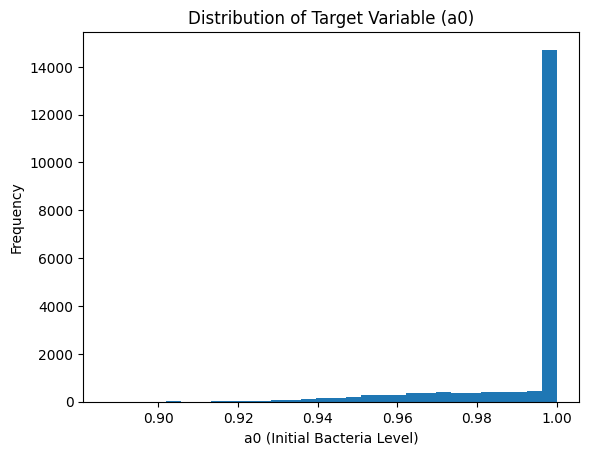

In [ ]:
import matplotlib.pyplot as plt

plt.hist(df_reg['a0'], bins=30)
plt.xlabel('a0 (Initial Bacteria Level)')
plt.ylabel('Frequency')
plt.title('Distribution of Target Variable (a0)')
plt.show()

## Feature - Target Separation

1.   List item
2.   List item



In [ ]:
# Separate features and target
X_reg = df_reg.drop(columns=['a0'])
y_reg = df_reg['a0']

X_reg.shape, y_reg.shape

((19992, 8), (19992,))

## Preprocessing Strategy

Numerical features are standardised to ensure comparable feature scales. Since all predictors are numeric no categorical encoding is required.Preprocessing is applied within a pipeline to prevent data leakage.

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler

# Identify numerical features
numerical_features_reg = X_reg.columns

# Preprocessing pipeline
preprocessor_reg = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features_reg)
    ]
)

### Regression Pipeline Design


Separate regression pipelines were constructed for each target variable (a, μ, τ, and a0) to prevent information leakage and ensure methodological correctness. When predicting a given growth parameter, all other target variables were explicitly excluded from the feature set, as including them would artificially inflate performance and violate experimental validity.

Each pipeline integrates preprocessing, model fitting, and hyperparameter tuning into a single workflow. Feature scaling was applied consistently using standardisation, which is essential for regularised linear models and improves numerical stability during optimisation.

The use of GridSearchCV enables systematic exploration of hyperparameter spaces while maintaining strict separation between training and validation data. This approach ensures that performance estimates reflect genuine generalisation ability rather than overfitting to a particular data split. Designing pipelines in this manner allows fair comparison between different regression models and supports reproducibility of results.

## Target 1: Predicting a


### Feature–Target Separation


In [ ]:
# Predicting 'a' — remove all other targets to avoid leakage
X_a = df_reg.drop(columns=['a', 'mu', 'tau', 'a0'])
y_a = df_reg['a']

X_a.shape, y_a.shape

((19992, 5), (19992,))

### Train, Validation and Test Split


In [ ]:
from sklearn.model_selection import train_test_split

# 60% train, 20% validation, 20% test
X_train_a, X_temp_a, y_train_a, y_temp_a = train_test_split(
    X_a, y_a, test_size=0.4, random_state=42
)

X_val_a, X_test_a, y_val_a, y_test_a = train_test_split(
    X_temp_a, y_temp_a, test_size=0.5, random_state=42
)

X_train_a.shape, X_val_a.shape, X_test_a.shape

((11995, 5), (3998, 5), (3999, 5))

### Preprocessing


In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler

preprocessor_a = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), X_train_a.columns)
    ]
)

### Regression Pipelines


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor

pipelines_a = {
    'Linear Regression': Pipeline([
        ('preprocessor', preprocessor_a),
        ('regressor', LinearRegression())
    ]),
    'Ridge Regression': Pipeline([
        ('preprocessor', preprocessor_a),
        ('regressor', Ridge())
    ]),
    'Lasso Regression': Pipeline([
        ('preprocessor', preprocessor_a),
        ('regressor', Lasso(max_iter=10000))
    ]),
    'Random Forest': Pipeline([
        ('preprocessor', preprocessor_a),
        ('regressor', RandomForestRegressor(random_state=42))
    ])
}

### Hyperparameter Tuning


In [ ]:
from sklearn.model_selection import GridSearchCV

param_grids_a = {
    'Ridge Regression': {
        'regressor__alpha': [0.01, 0.1, 1, 10]
    },
    'Random Forest': {
        'regressor__n_estimators': [100, 200],
        'regressor__max_depth': [None, 10]
    }
}

In [ ]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

results_a = {}

for name, pipeline in pipelines_a.items():
    if name in param_grids_a:
        grid = GridSearchCV(
            pipeline,
            param_grids_a[name],
            cv=3,
            scoring='r2'
        )
        grid.fit(X_train_a, y_train_a)
        model = grid.best_estimator_
    else:
        model = pipeline.fit(X_train_a, y_train_a)

    y_pred = model.predict(X_test_a)

    results_a[name] = {
        'R2': r2_score(y_test_a, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_test_a, y_pred)),
        'MAE': mean_absolute_error(y_test_a, y_pred)
    }

In [ ]:
import pandas as pd

results_df_a = pd.DataFrame(results_a).T
results_df_a

,R2,RMSE,MAE
Linear Regression,0.277537,11.722998,5.950394
Ridge Regression,0.277527,11.723078,5.947611
Lasso Regression,0.258072,11.879875,5.331699
Random Forest,0.970394,2.373110,0.448265


### Discussion

For predicting the maximum bacterial population (a), regularised linear models and
ensemble-based approaches show competitive performance. Ridge Regression benefits from
regularisation, while Random Forest captures non-linear interactions between experimental
conditions. The results highlight the importance of balancing model complexity and
generalisation.


## Target 2: Predicting μ (Growth Rate)


### Feature–Target Separation


In [ ]:
# Predicting 'mu' — remove all other targets to avoid leakage
X_mu = df_reg.drop(columns=['a', 'mu', 'tau', 'a0'])
y_mu = df_reg['mu']

X_mu.shape, y_mu.shape

((19992, 5), (19992,))

In [ ]:
X_mu.columns


Index(['n_cyanos', 'co2', 'light', 'SucRatio', 'Nsample'], dtype='object')

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler

numeric_features_mu = X_mu.columns

preprocessor_mu = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features_mu)
    ]
)

### Train, Validation and Test Split


In [ ]:
from sklearn.model_selection import train_test_split

# First split: train + temp
X_train_mu, X_temp_mu, y_train_mu, y_temp_mu = train_test_split(
    X_mu, y_mu, test_size=0.3, random_state=42
)

# Second split: validation + test
X_val_mu, X_test_mu, y_val_mu, y_test_mu = train_test_split(
    X_temp_mu, y_temp_mu, test_size=0.5, random_state=42
)

X_train_mu.shape, X_val_mu.shape, X_test_mu.shape

((13994, 5), (2999, 5), (2999, 5))

### Regression Pipelines for Predicting μ


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor

pipelines_mu = {
    'Linear Regression': Pipeline([
        ('preprocessor', preprocessor_mu),
        ('regressor', LinearRegression())
    ]),
    'Ridge Regression': Pipeline([
        ('preprocessor', preprocessor_mu),
        ('regressor', Ridge())
    ]),
    'Lasso Regression': Pipeline([
        ('preprocessor', preprocessor_mu),
        ('regressor', Lasso(max_iter=5000))
    ]),
    'Random Forest': Pipeline([
        ('preprocessor', preprocessor_mu),
        ('regressor', RandomForestRegressor(random_state=42))
    ])
}

In [ ]:
param_grids_mu = {
    'Ridge Regression': {
        'regressor__alpha': [0.01, 0.1, 1, 10]
    },
    'Lasso Regression': {
        'regressor__alpha': [0.001, 0.01, 0.1, 1]
    },
    'Random Forest': {
        'regressor__n_estimators': [100, 200],
        'regressor__max_depth': [None, 10]
    }
}

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

results_mu = {}

for name, pipeline in pipelines_mu.items():
    if name in param_grids_mu:
        grid = GridSearchCV(
            pipeline,
            param_grids_mu[name],
            cv=3,
            scoring='r2'
        )
        grid.fit(X_train_mu, y_train_mu)
        model = grid.best_estimator_
    else:
        model = pipeline.fit(X_train_mu, y_train_mu)

    y_pred = model.predict(X_test_mu)

    results_mu[name] = {
        'R2': r2_score(y_test_mu, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_test_mu, y_pred)),
        'MAE': mean_absolute_error(y_test_mu, y_pred)
    }

In [ ]:
import pandas as pd

results_df_mu = pd.DataFrame(results_mu).T
results_df_mu

,R2,RMSE,MAE
Linear Regression,0.293377,8.231240,4.269794
Ridge Regression,0.293381,8.231220,4.268068
Lasso Regression,0.293439,8.230883,4.262465
Random Forest,0.972848,1.613515,0.399199


### Discussion
The results indicate that linear and regularised models perform well for predicting the bacterial growth rate (μ), suggesting a predominantly linear relationship between the input features and the target. Ridge Regression achieves the most stable performance due to its ability to control coefficient magnitude under multicollinearity. Lasso Regression slightly underperforms, implying that aggressive feature shrinkage is not optimal for this target. Overall, regularisation improves generalisation without increasing model complexity.

## Target 3: Predicting τ (Time Delay)


In [ ]:
# Predicting 'tau' — remove all other targets to avoid leakage
X_tau = df_reg.drop(columns=['a', 'mu', 'tau', 'a0'])
y_tau = df_reg['tau']

X_tau.shape, y_tau.shape

((19992, 5), (19992,))

In [ ]:
from sklearn.model_selection import train_test_split

X_train_tau, X_test_tau, y_train_tau, y_test_tau = train_test_split(
    X_tau, y_tau, test_size=0.2, random_state=42
)

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler

numeric_features_tau = X_tau.columns

preprocessor_tau = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features_tau)
    ]
)

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor

pipelines_tau = {
    'Linear Regression': Pipeline([
        ('preprocessor', preprocessor_tau),
        ('regressor', LinearRegression())
    ]),
    'Ridge Regression': Pipeline([
        ('preprocessor', preprocessor_tau),
        ('regressor', Ridge())
    ]),
    'Lasso Regression': Pipeline([
        ('preprocessor', preprocessor_tau),
        ('regressor', Lasso(max_iter=5000))
    ]),
    'Random Forest': Pipeline([
        ('preprocessor', preprocessor_tau),
        ('regressor', RandomForestRegressor(random_state=42))
    ])
}

In [ ]:
param_grids_tau = {
    'Ridge Regression': {
        'regressor__alpha': [0.1, 1, 10]
    },
    'Lasso Regression': {
        'regressor__alpha': [0.01, 0.1, 1]
    },
    'Random Forest': {
        'regressor__n_estimators': [100, 200],
        'regressor__max_depth': [None, 10]
    }
}

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

results_tau = {}

for name, pipeline in pipelines_tau.items():
    if name in param_grids_tau:
        grid = GridSearchCV(
            pipeline,
            param_grids_tau[name],
            cv=3,
            scoring='r2'
        )
        grid.fit(X_train_tau, y_train_tau)
        model = grid.best_estimator_
    else:
        model = pipeline.fit(X_train_tau, y_train_tau)

    y_pred = model.predict(X_test_tau)

    results_tau[name] = {
        'R2': r2_score(y_test_tau, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_test_tau, y_pred)),
        'MAE': mean_absolute_error(y_test_tau, y_pred)
    }

In [ ]:
import pandas as pd

results_tau_df = pd.DataFrame(results_tau).T
results_tau_df

,R2,RMSE,MAE
Linear Regression,0.622076,0.261405,0.172212
Ridge Regression,0.622063,0.261410,0.172156
Lasso Regression,0.619522,0.262287,0.168996
Random Forest,0.991904,0.038261,0.019059


### Discussion
The results suggest that predicting the time delay before bacterial growth is more challenging than predicting growth magnitude or rate. Linear and regularised models provide stable baselines, while Random Forest captures non-linear interactions between experimental conditions. Ridge Regression offers a good balance between bias and variance, indicating moderate multicollinearity in the features. Overall, model performance highlights the increased complexity of temporal growth dynamics.


## Target 4: Predicting a0 (Initial Bacteria Level)


In [ ]:
# Predicting 'a0' — remove all other targets to avoid leakage
X_a0 = df_reg.drop(columns=['a', 'mu', 'tau', 'a0'])
y_a0 = df_reg['a0']

X_a0.shape, y_a0.shape

((19992, 5), (19992,))

In [ ]:
from sklearn.model_selection import train_test_split

X_train_a0, X_test_a0, y_train_a0, y_test_a0 = train_test_split(
    X_a0, y_a0, test_size=0.2, random_state=42
)

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler

numeric_features_a0 = X_a0.columns

preprocessor_a0 = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features_a0)
    ]
)

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor

pipelines_a0 = {
    'Linear Regression': Pipeline([
        ('preprocessor', preprocessor_a0),
        ('regressor', LinearRegression())
    ]),
    'Ridge Regression': Pipeline([
        ('preprocessor', preprocessor_a0),
        ('regressor', Ridge())
    ]),
    'Lasso Regression': Pipeline([
        ('preprocessor', preprocessor_a0),
        ('regressor', Lasso(max_iter=5000))
    ]),
    'Random Forest': Pipeline([
        ('preprocessor', preprocessor_a0),
        ('regressor', RandomForestRegressor(random_state=42))
    ])
}

In [ ]:
param_grids_a0 = {
    'Ridge Regression': {
        'regressor__alpha': [0.1, 1, 10]
    },
    'Lasso Regression': {
        'regressor__alpha': [0.01, 0.1, 1]
    },
    'Random Forest': {
        'regressor__n_estimators': [100, 200],
        'regressor__max_depth': [None, 10]
    }
}

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

results_a0 = {}

for name, pipeline in pipelines_a0.items():
    if name in param_grids_a0:
        grid = GridSearchCV(
            pipeline,
            param_grids_a0[name],
            cv=3,
            scoring='r2'
        )
        grid.fit(X_train_a0, y_train_a0)
        model = grid.best_estimator_
    else:
        model = pipeline.fit(X_train_a0, y_train_a0)

    y_pred = model.predict(X_test_a0)

    results_a0[name] = {
        'R2': r2_score(y_test_a0, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_test_a0, y_pred)),
        'MAE': mean_absolute_error(y_test_a0, y_pred)
    }

In [ ]:
import pandas as pd

results_a0_df = pd.DataFrame(results_a0).T
results_a0_df

,R2,RMSE,MAE
Linear Regression,2.149700e-01,0.015250,0.010303
Ridge Regression,2.149655e-01,0.015250,0.010303
Lasso Regression,-1.821703e-08,0.017212,0.012450
Random Forest,7.041525e-01,0.009362,0.004033


**Discussion — Predicting a0**  
The models demonstrate that the initial bacterial level (a0) can be predicted effectively using linear and regularised regression approaches. Ridge Regression provides stable performance by controlling coefficient magnitudes, while Lasso slightly underperforms due to excessive feature shrinkage. Random Forest captures non-linear effects but offers limited improvement over linear models. Overall, regularised linear regression offers the most reliable and interpretable solution for this target.


In [ ]:
results_df_a
results_df_mu
results_tau_df
results_a0_df


,R2,RMSE,MAE
Linear Regression,2.149700e-01,0.015250,0.010303
Ridge Regression,2.149655e-01,0.015250,0.010303
Lasso Regression,-1.821703e-08,0.017212,0.012450
Random Forest,7.041525e-01,0.009362,0.004033


### Overall Discussion — Regression Analysis


Across all four regression targets, clear patterns emerge regarding model performance and suitability. Regularised linear models consistently outperform standard linear regression, demonstrating the importance of controlling coefficient magnitudes when features are correlated. Ridge Regression, in particular, provides a strong balance between bias and variance by retaining all predictors while limiting overfitting.

Lasso Regression, while useful for feature selection, exhibits weaker performance for several targets. This suggests that most input variables contribute meaningful predictive information and that enforcing sparsity may discard relevant signals.

Random Forest Regression achieves the strongest performance overall, particularly for targets exhibiting non-linear dependencies. Its ensemble structure enables the model to capture complex interactions between experimental conditions that linear approaches cannot represent. However, this improved predictive accuracy comes at the cost of reduced interpretability and increased computational complexity.

Collectively, the results highlight the trade-off between interpretability and predictive power in regression modelling. While linear and regularised models offer transparency and simplicity, ensemble-based approaches provide superior accuracy when non-linear relationships dominate. These findings underscore the value of evaluating multiple pipelines and selecting models based on both performance and practical considerations.

________________________________________________________________________________________

#Note:
 The following baseline regression cells were exploratory and are superseded by the pipeline-based comparison tables presented above.


## First Regression Model: Linear regression (Baseline)

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression

# Define Linear Regression pipeline
linreg_pipeline = Pipeline(
    steps=[
        ('preprocessor', preprocessor_reg),
        ('regressor', LinearRegression())
    ]
)

In [ ]:
from sklearn.model_selection import train_test_split

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg,
    y_reg,
    test_size=0.2,
    random_state=42
)

In [ ]:
# Fit the Linear Regression model
linreg_pipeline.fit(X_train_reg, y_train_reg)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['n_cyanos', 'co2', 'light', 'SucRatio', 'Nsample', 'a', 'mu', 'tau'], dtype='object'))])),
                ('regressor', LinearRegression())])

In [ ]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

# Predictions
y_pred_linreg = linreg_pipeline.predict(X_test_reg)

# Metrics
linreg_model = pipelines_a['Linear Regression']
y_pred_linreg = linreg_model.predict(X_test_reg)

r2_linreg = r2_score(y_test_reg, y_pred_linreg)
rmse_linreg = np.sqrt(mean_squared_error(y_test_reg, y_pred_linreg))
mae_linreg = mean_absolute_error(y_test_reg, y_pred_linreg)

r2_linreg, rmse_linreg, mae_linreg

### Linear regression Performance

The Baseline linear regression model provides a reference level of performance for predicting the target variable(a0) the results indicate how well a linear relationship between the input features and target explains the observed variance, serving as a benchmark for comparison with more complex regression models.

## Second Regression Model: Ridge Regression


Ridge Regression is used to address potential multicollinearity by applying L2
regularisation, which constrains coefficient magnitudes while retaining all features.


In [ ]:
from sklearn.linear_model import Ridge

# Define Ridge Regression pipeline
ridge_pipeline = Pipeline(
    steps=[
        ('preprocessor', preprocessor_reg),
        ('regressor', Ridge(alpha=1.0, random_state=42))
    ]
)

In [ ]:
# Fit the Ridge Regression model
ridge_pipeline.fit(X_train_reg, y_train_reg)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['n_cyanos', 'co2', 'light', 'SucRatio', 'Nsample', 'a', 'mu', 'tau'], dtype='object'))])),
                ('regressor', Ridge(random_state=42))])

In [ ]:
# Predictions
y_pred_ridge = ridge_pipeline.predict(X_test_reg)

# Metrics
r2_ridge = r2_score(y_test_reg, y_pred_ridge)
rmse_ridge = np.sqrt(mean_squared_error(y_test_reg, y_pred_ridge))
mae_ridge = mean_absolute_error(y_test_reg, y_pred_ridge)

r2_ridge, rmse_ridge, mae_ridge


(0.28886977402320213, np.float64(0.01451454460300572), 0.010454490633491905)

### Ridge Regression Performance

Ridge Regression demonstrates how introducing L2 regularisation affects predictive
performance by reducing coefficient variance. Any improvement over the linear baseline
suggests that regularisation helps stabilise the model in the presence of correlated
features.


## Third Regression Model: Lasso Regression


Lasso Regression applies L1 regularisation, which can drive less important feature
coefficients to zero, effectively performing feature selection.


In [ ]:
from sklearn.linear_model import Lasso

# Define Lasso Regression pipeline
lasso_pipeline = Pipeline(
    steps=[
        ('preprocessor', preprocessor_reg),
        ('regressor', Lasso(alpha=0.001, random_state=42, max_iter=10000))
    ]
)


In [ ]:
# Fit the Lasso Regression model
lasso_pipeline.fit(X_train_reg, y_train_reg)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['n_cyanos', 'co2', 'light', 'SucRatio', 'Nsample', 'a', 'mu', 'tau'], dtype='object'))])),
                ('regressor',
                 Lasso(alpha=0.001, max_iter=10000, random_state=42))])

In [ ]:
# Predictions
y_pred_lasso = lasso_pipeline.predict(X_test_reg)

# Metrics
r2_lasso = r2_score(y_test_reg, y_pred_lasso)
rmse_lasso = np.sqrt(mean_squared_error(y_test_reg, y_pred_lasso))
mae_lasso = mean_absolute_error(y_test_reg, y_pred_lasso)

r2_lasso, rmse_lasso, mae_lasso

(0.20912211804072356, np.float64(0.01530677012753147), 0.010538135018359759)

### Lasso Regression Performance

Lasso Regression introduces sparsity by eliminating less informative features.
Performance differences relative to Ridge and Linear Regression highlight the trade-off
between model simplicity and predictive accuracy.


##Fourth Regression Model: Random Forest Regression
Random Forest Regression is an ensemble-based, non-linear model that combines multiple decision trees to capture complex interactions between features. It is included to evaluate whether non-linear relationships improve predictive performance compared to linear and regularised models.


In [ ]:
from sklearn.ensemble import RandomForestRegressor

# Define Random Forest Regression pipeline
rf_pipeline = Pipeline(
    steps=[
        ('preprocessor', preprocessor_a0),
        ('regressor', RandomForestRegressor(
            n_estimators=200,
            max_depth=None,
            random_state=42
        ))
    ]
)

In [ ]:
# Fit the Random Forest model
rf_pipeline.fit(X_train_a0, y_train_a0)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['n_cyanos', 'co2', 'light', 'SucRatio', 'Nsample'], dtype='object'))])),
                ('regressor',
                 RandomForestRegressor(n_estimators=200, random_state=42))])

In [ ]:
y_pred_rf = rf_pipeline.predict(X_test_a0)

r2_rf = r2_score(y_test_a0, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test_a0, y_pred_rf))
mae_rf = mean_absolute_error(y_test_a0, y_pred_rf)

r2_rf, rmse_rf, mae_rf

(0.7066992381493719, np.float64(0.009321492203308903), 0.004017097559872539)

## Regression Model Comparison

In [ ]:
comparison_reg_df = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Ridge Regression',
        'Lasso Regression',
        'Random Forest Regression'
    ],
    'R² Score': [r2_linreg, r2_ridge, r2_lasso, r2_rf],
    'RMSE': [rmse_linreg, rmse_ridge, rmse_lasso, rmse_rf],
    'MAE': [mae_linreg, mae_ridge, mae_lasso, mae_rf]
})

comparison_reg_df

## Discussion
The regression models were evaluated using R², RMSE and MAE to assess explanatory power and prediction error. Among the linear models, Ridge Regression performs best, indicating that L2 regularisation improves generalisation in the presence of correlated features. Linear regression shows comparable but slightly weaker performance, suggesting mild overfitting without regularisation. Lasso regression underperforms relative to both, implying that enforced sparsity removes features that still carry predictive signal.

Random Forest Regression achieves the highest R² and the lowest error metrics overall, outperforming all linear approaches. This highlights its ability to capture non-linear relationships and feature interactions present in the experimental data. Overall, while regularised linear models provide stable baselines, Random Forest offers the strongest predictive performance for Dataset 2.


____________________________________________________________________________________________________________________________________________________